PROJECT SUMMARY IS IN THE END - THANK YOU.



In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')


In [28]:
salary_data = pd.read_csv('../ML CODE/Data/Salary_dataset.csv')

In [29]:
salary_data

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [30]:
# #  The Roadmap

# This is the workflow we'll follow.

# 1. Understand the Dataset
#         ↓
# 2. Ask Questions Before Coding
#         ↓
# 3. Exploratory Data Analysis (EDA)
#         ↓
# 4. Data Cleaning
#         ↓
# 5. Feature Engineering (if needed)
#         ↓
# 6. Preprocessing
#         ↓
# 7. Train-Test Split
#         ↓
# 8. Build Linear Regression Model
#         ↓
# 9. Evaluate the Model
#         ↓
# 10. Improve the Model
#         ↓
# 11. Interpret Results
#         ↓
# 12. Save the Model

In [31]:
# 🎯 Question 1
# # Is this a Regression problem or a Classification problem?

# Don't just say "Regression."

# Tell me why.

# 🎯 Question 2

# Which column is our target variable?

# 🎯 Question 3

# Which column(s) are our features?

# 🎯 Question 4

# There are 3 columns.

# Do you notice one column that already looks suspicious?

In [32]:
# EDA
# EDA isn't just running functions—it's asking questions about the data.

In [33]:
salary_data.shape

(30, 3)

In [34]:
salary_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [35]:
salary_data.describe()
# describe() helps us understand each column individually.

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [36]:
# Step 4 — Visualization

# Before writing the code...

# I want you to think.

# Question 1

# Imagine I asked you:

# "Does salary increase as experience increases?"

# What graph would you use?

# Choose one:

# A)

# Histogram

# B)

# Boxplot

# C)

# Scatter Plot

# D)

# Pie Chart

# Question 2

# More importantly...

# WHY?

# 📊 Histogram

# Question it answers:

# "How are the values distributed?"

# Example:

# Suppose I only care about Salary.

# I want to know

# Most salaries around 50k?
# Around 100k?
# Is it skewed?
# Is it normally distributed?

# A histogram is perfect.

# 📈 Scatter Plot

# Now suppose my question changes.

# Instead of asking

# "How are salaries distributed?"

# I ask

# "Does salary change when experience changes?"

# Now I have two variables.

# Experience

# ↓

# Salary

# Every employee becomes one point.

# 🥧 Pie Chart

# Question:

# "What percentage belongs to each category?"

# Example:

# Departments

# HR 20%

# IT 40%

# Sales 25%

# Finance 15%

# That's all.

# Pie charts are almost never used in Machine Learning.

In [37]:
# Question	Best Graph
# Distribution of one numerical column?	Histogram
# Relationship between two numerical columns?	Scatter Plot
# Detect outliers?	Box Plot
# Compare categories?	Bar Plot
# Percentage of categories?	Pie Chart (rare in ML)

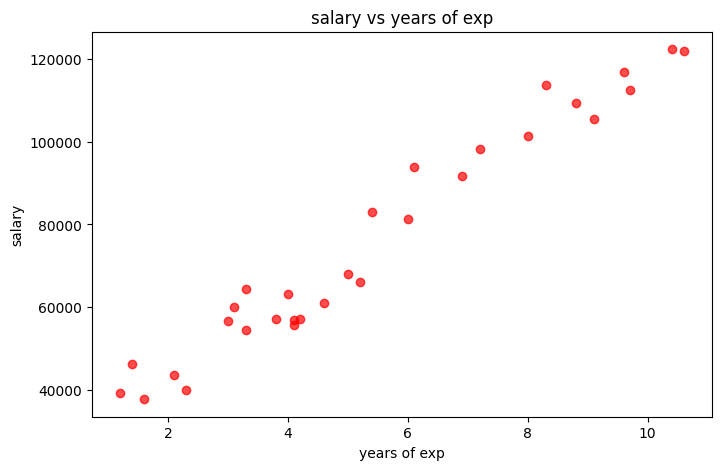

In [38]:
plt.figure(figsize=(8,5))

X = salary_data[['YearsExperience']]
y = salary_data['Salary']

plt.scatter(X, y, color='red', alpha=0.7)

plt.xlabel('years of exp')
plt.ylabel('salary')
plt.title('salary vs years of exp')

plt.show()

In [39]:
# Question 1

# Do the points look

# A)

# Random

# B)

# Increasing

# C)

# Decreasing

# Question 2

# Can you imagine drawing one straight line that roughly passes through most of those points?

# Yes or No?

# Question 3

# Do you think Linear Regression is a reasonable algorithm for this dataset?

# Why?

# Question 4 (Most Important)

# Suppose the graph looked like this instead.

# Salary

# 120K        ●

# 110K

# 100K   ●

# 90K

# 80K

# 70K         ●

# 60K

# 50K  ●

# 40K

# 30K        ●

# -----------------------------

# 1   2   3   4   5

# Would Linear Regression still be a good choice?

# Why?

# Think before answering.

In [40]:
# Pre processing 
salary_data = salary_data.drop(columns='Unnamed: 0')



In [41]:
salary_data


,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [42]:
# # # TRAIN TEST SPLIT
# # The test set represents data the model has never seen before.
# # Can my model make good predictions on new, unseen data?

# What We Actually Want

# Training Data

# 1 year

# 2 years

# 3 years

# 5 years

# 8 years

# Testing Data

# 4 years

# 6 years

# 9 years


# This is called...

# Generalization.

# This is one of the most important words in Machine Learning.

# A good model is not one that performs well on the training data.

# A good model is one that generalizes well to new, unseen data.

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
model = LinearRegression()

In [50]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.438e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [52]:
y_pred = model.predict(X_test)
print(y_pred)
print(y_test)

[115791.21011287  71499.27809463 102597.86866063  75268.80422384
  55478.79204548  60190.69970699]
27    112636.0
15     67939.0
23    113813.0
17     83089.0
8      64446.0
9      57190.0
Name: Salary, dtype: float64


In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
r2 = r2_score(y_test, y_pred)

# mae -> "On average, my predictions are off by about ₹6286.453830757745
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

In [56]:
print("R² Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R² Score: 0.9024461774180498
MAE: 6286.453830757745
MSE: 49830096.855908334
RMSE: 7059.043621901506


# PROJECT SUMMARY

# 📘 Project 1 Summary – Salary Prediction using Linear Regression

## 🎯 Objective

The goal of this project was to build a Machine Learning model that predicts an employee's salary based on their years of experience using **Linear Regression**.

More importantly, this project was focused on understanding the complete ML workflow rather than just training a model.

---

# Step 1: Understanding the Problem

Before writing any code, we first understood the dataset.

**Dataset Columns:**

* `Unnamed: 0`
* `YearsExperience`
* `Salary`

We identified:

* **Target Variable (y):** Salary
* **Feature (X):** YearsExperience

Since salary is a **continuous numerical value**, this is a **Regression** problem.

---

# Step 2: Exploratory Data Analysis (EDA)

We explored the dataset using Pandas.

### Functions Used

* `shape`
* `info()`
* `describe()`

### Observations

* Dataset contains **30 rows**.
* No missing values.
* Data types were appropriate (`int64` and `float64`).
* Experience ranges from **1.2 to 10.6 years**.
* Salary ranges from approximately **₹37,000 to ₹122,000**.
* The dataset is clean and requires very little preprocessing.

---

# Step 3: Data Visualization

We created a **Scatter Plot** to study the relationship between the feature and the target.

### Why Scatter Plot?

A scatter plot is ideal when analyzing the relationship between **two numerical variables**.

It helped us answer:

* Does salary increase with experience?
* Is the relationship approximately linear?
* Is Linear Regression a suitable algorithm?

### Observation

The points showed a clear **positive linear trend**, making Linear Regression an appropriate choice.

---

# Step 4: Data Preprocessing

We removed the unnecessary column:

* `Unnamed: 0`

Reason:

It was simply an index and contained no meaningful information for predicting salary.

Then we prepared the data:

* **X (Features):** YearsExperience
* **y (Target):** Salary

---

# Step 5: Train-Test Split

We divided the dataset into:

* **80% Training Data**
* **20% Testing Data**

Purpose:

The model learns from the training data and is evaluated on unseen test data to measure how well it generalizes instead of simply memorizing the training examples.

We also used:

`random_state = 42`

This ensures that the train-test split remains consistent every time the notebook is executed, making experiments reproducible.

---

# Step 6: Training the Model

We imported the Linear Regression model from Scikit-learn and trained it using:

`model.fit(X_train, y_train)`

During training, the model learned the best-fit line that describes the relationship between years of experience and salary.

---

# Step 7: Making Predictions

After training, we predicted salaries for the unseen test data using:

`model.predict(X_test)`

These predictions were then compared with the actual salaries.

---

# Step 8: Model Evaluation

We evaluated the model using four different metrics.

### R² Score

**Result:** 0.9024

Interpretation:

The model explains approximately **90.2% of the variation in salary** using years of experience.

---

### Mean Absolute Error (MAE)

**Result:** ₹6,286

Interpretation:

On average, the model's predictions differ from the actual salary by about **₹6,286**.

---

### Mean Squared Error (MSE)

**Result:** 49,830,096

Interpretation:

This metric squares prediction errors, giving larger mistakes more weight. It is primarily useful during optimization rather than for business interpretation.

---

### Root Mean Squared Error (RMSE)

**Result:** ₹7,059

Interpretation:

The model's typical prediction error is approximately **₹7,059**, expressed in the same unit as salary.

---

# What We Learned

This project helped build a complete understanding of the Linear Regression workflow.

Key concepts learned:

* Difference between Regression and Classification.
* How to identify features and target variables.
* Performing basic Exploratory Data Analysis (EDA).
* Choosing the correct visualization for the problem.
* Why Scatter Plots are used for regression.
* Why unnecessary columns should be removed.
* The purpose of Train-Test Split.
* The importance of `random_state`.
* Difference between `fit()`, `transform()`, `fit_transform()`, and `predict()`.
* How Linear Regression learns the best-fit line.
* How to evaluate a regression model using R², MAE, MSE, and RMSE.
* Why a good model should generalize to unseen data instead of memorizing the training data.

---

# Final Conclusion

The Linear Regression model performed well on this dataset with an R² score of approximately **0.90**, indicating a strong linear relationship between years of experience and salary.

However, salary is influenced by many additional factors such as education, skills, job role, company, location, and industry. Since this dataset only included **YearsExperience** as the feature, the model cannot explain all variations in salary.

This project established a strong foundation in Linear Regression and provided a complete end-to-end understanding of the Machine Learning workflow—from problem understanding and data exploration to preprocessing, model building, prediction, and evaluation.

It serves as the first step toward mastering regression problems and developing a professional Machine Learning portfolio.
